# Blackjack: modelo MDP e iteración de valores

Este notebook construye **P desde las reglas de Blackjack**, aplica Bellman hasta la convergencia y compara la política obtenida con decisiones aleatorias en 100 partidas de `Blackjack-v1`.

El entorno usa una baraja infinita. Por ello, cada extracción es independiente y tiene la misma distribución. Usamos `natural=False, sab=False`, de modo que la observación `(suma, carta visible, as utilizable)` basta para predecir las consecuencias de las acciones.

In [1]:
# Si hace falta, ejecutar una sola vez en una celda aparte:
# %pip install "gymnasium[toy-text]" numpy pandas matplotlib

In [2]:
from collections import defaultdict
from functools import lru_cache

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

## Funciones auxiliares para el experimento final

Primero definimos las funciones que utilizaremos al final. En el experimento, una **iteración equivale a una partida completa** y ejecutaremos exactamente 100 partidas para cada agente:

1. **Agente aleatorio (sin conocimiento):** elige `HIT` o `STICK` al azar con probabilidad 50/50.
2. **Agente Bellman (con conocimiento):** consulta `policy_opt`, la política obtenida mediante propagación de valores.

Las cartas seguirán siendo aleatorias en ambos experimentos. Lo que cambiará será la forma de escoger las acciones. Estas funciones se ejecutarán después de calcular la política óptima.

In [3]:
def simulate_100_games(policy_function, agent_name, episodes=100, seed=2026):
    simulation_env = gym.make("Blackjack-v1", natural=False, sab=False)
    rng = np.random.default_rng(seed)
    records = []

    for episode in range(1, episodes + 1):
        state, info = simulation_env.reset(seed=seed + episode - 1)
        initial_state = state
        actions = []
        terminated = truncated = False

        while not (terminated or truncated):
            action = policy_function(state, rng)
            actions.append("HIT" if action == HIT else "STICK")
            state, reward, terminated, truncated, info = simulation_env.step(action)

        records.append({
            "agente": agent_name,
            "partida": episode,
            "estado_inicial": initial_state,
            "acciones": " -> ".join(actions),
            "recompensa": int(reward),
            "resultado": "Victoria" if reward == 1 else ("Empate" if reward == 0 else "Derrota"),
        })

    simulation_env.close()
    history = pd.DataFrame(records)
    history["recompensa_acumulada"] = history["recompensa"].cumsum()
    history["recompensa_media_acumulada"] = history["recompensa"].expanding().mean()
    history["tasa_victorias_acumulada"] = (history["recompensa"] == 1).expanding().mean()
    return history
def random_policy(state, rng):
    return int(rng.integers(0, 2))


def optimal_policy(state, rng):
    normalized_state = (state[0], state[1], bool(state[2]))
    return policy_opt[normalized_state]




In [4]:
def experiment_summary(history):
    rewards = history["recompensa"]
    return pd.Series({
        "partidas": len(history),
        "victorias": int((rewards == 1).sum()),
        "empates": int((rewards == 0).sum()),
        "derrotas": int((rewards == -1).sum()),
        "recompensa total": int(rewards.sum()),
        "recompensa media": rewards.mean(),
        "porcentaje de victorias": 100 * (rewards == 1).mean(),
    })

In [5]:
def plot_100_games(random_history, informed_history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    for history, label in [
        (random_history, "Aleatorio"),
        (informed_history, "Bellman"),
    ]:
        axes[0].plot(history["partida"], history["recompensa_acumulada"], label=label)
        axes[1].plot(history["partida"], history["recompensa_media_acumulada"], label=label)

    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title("Recompensa acumulada")
    axes[0].set_xlabel("Partida")
    axes[0].set_ylabel("Suma de recompensas")
    axes[0].legend()

    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title("Recompensa media hasta cada partida")
    axes[1].set_xlabel("Partida")
    axes[1].set_ylabel("Recompensa media")
    axes[1].legend()

    outcome_counts = pd.DataFrame({
        "Aleatorio": random_history["resultado"].value_counts(),
        "Bellman": informed_history["resultado"].value_counts(),
    }).fillna(0).reindex(["Victoria", "Empate", "Derrota"])
    outcome_counts.plot.bar(ax=axes[2], rot=0, color=["#E45756", "#4C78A8"])
    axes[2].set_title("Resultados después de 100 partidas")
    axes[2].set_xlabel("Resultado")
    axes[2].set_ylabel("Número de partidas")

    plt.show()

### Nota sobre estas funciones

Estas celdas solamente definen cómo registrar, resumir y graficar las partidas. Todavía no ejecutan el experimento porque antes necesitamos calcular `policy_opt`.

La comparación se ejecuta en la sección 9, después de obtener la política mediante Bellman.

## 1. Planteamiento del problema como MDP

- **Estados no terminales:** `s = (suma del jugador, carta visible del crupier, as utilizable)`. La carta visible vale 1 para as y 2–10 para las demás. Un as utilizable cuenta como 11 sin pasarse de 21.
- **Acciones:** `0 = STICK` (plantarse) y `1 = HIT` (pedir carta).
- **Estados terminales:** `WIN`, `DRAW` y `LOSS`; representan ganar, empatar y perder. Una mano que supera 21 termina en `LOSS`.
- **Recompensa:** `+1`, `0` y `-1` al terminar en `WIN`, `DRAW` y `LOSS`, respectivamente. Los pasos no terminales dan 0.
- **Factor de descuento:** `γ = 1`. Cada episodio termina en un número finito de cartas; así maximizamos el resultado esperado de la partida sin descontarlo.
- **Transición:** `P(s' | s, a)` se calcula con la distribución infinita de cartas. Para `HIT` se agrega la probabilidad de cada carta que lleva al mismo estado. Para `STICK` se agrega la probabilidad del resultado final del crupier, incluida su carta oculta y sus extracciones hasta sumar 17 o más.

**Ecuación de Bellman:**

`V_{k+1}(s) = max_a Σ_{(p,s',r,done) ∈ P[s][a]} p · [r + γ · (1-done) · V_k(s')]`.

Aquí `P[s][a]` es una lista de transiciones `(probabilidad, siguiente_estado, recompensa, terminó)`; el valor futuro de un estado terminal es cero.

In [6]:
env = gym.make("Blackjack-v1", natural=False, sab=False)
state, info = env.reset(seed=42)

print("Estado inicial:         ", state)
print("Espacio de estados:     ", env.observation_space)
print("Espacio de acciones:    ", env.action_space)
print("¿El entorno publica P?: ", hasattr(env.unwrapped, "P"))

Estado inicial:          (15, 2, 0)
Espacio de estados:      Tuple(Discrete(32), Discrete(11), Discrete(2))
Espacio de acciones:     Discrete(2)
¿El entorno publica P?:  False


## 2. Modelo de las cartas

Gymnasium usa una baraja infinita: después de cada extracción la distribución permanece igual. Los valores `1` a `9` tienen probabilidad `1/13`; el valor `10` tiene probabilidad `4/13`, porque representa 10, J, Q y K.

In [7]:
CARD_PROBS = {card: 1 / 13 for card in range(1, 10)}
CARD_PROBS[10] = 4 / 13

assert np.isclose(sum(CARD_PROBS.values()), 1.0)
pd.Series(CARD_PROBS, name="probabilidad").rename_axis("valor de carta")

valor de carta
1     0.076923
2     0.076923
3     0.076923
4     0.076923
5     0.076923
6     0.076923
7     0.076923
8     0.076923
9     0.076923
10    0.307692
Name: probabilidad, dtype: float64

El as vale 11 mientras no produzca una suma mayor a 21. Si lo hiciera, pasa a valer 1. La siguiente función reproduce ese comportamiento usando solamente la suma actual y el indicador de as utilizable.

In [8]:
def add_card(total, usable_ace, card):
    if usable_ace:
        new_total = total + card
        if new_total > 21:
            return new_total - 10, False  # el as cambia de 11 a 1
        return new_total, True

    new_total = total + card
    if card == 1 and new_total + 10 <= 21:
        return new_total + 10, True
    return new_total, False

print("Soft 18 + 5 ->", add_card(18, True, 5))
print("10 + as      ->", add_card(10, False, 1))

Soft 18 + 5 -> (13, False)
10 + as      -> (21, True)


## 3. Probabilidades del resultado final del crupier

Cuando el jugador se planta, el crupier pide cartas hasta alcanzar por lo menos 17. La recursión siguiente calcula la distribución exacta de sus resultados finales, condicionada a la carta visible.

In [9]:
@lru_cache(maxsize=None)
def dealer_play(total, usable_ace):
    if total >= 17:
        return {total: 1.0}

    outcomes = defaultdict(float)
    for card, card_prob in CARD_PROBS.items():
        next_total, next_usable = add_card(total, usable_ace, card)

        if next_total > 21:
            outcomes["bust"] += card_prob
        else:
            for result, result_prob in dealer_play(next_total, next_usable).items():
                outcomes[result] += card_prob * result_prob

    return dict(outcomes)


def dealer_distribution(showing_card):
    if showing_card == 1:
        visible_total, visible_usable = 11, True
    else:
        visible_total, visible_usable = showing_card, False

    outcomes = defaultdict(float)
    for hidden_card, hidden_prob in CARD_PROBS.items():
        total, usable = add_card(visible_total, visible_usable, hidden_card)
        for result, result_prob in dealer_play(total, usable).items():
            outcomes[result] += hidden_prob * result_prob

    assert np.isclose(sum(outcomes.values()), 1.0)
    return dict(outcomes)


DEALER_DISTS = {card: dealer_distribution(card) for card in range(1, 11)}
dealer_table = pd.DataFrame(DEALER_DISTS).T.fillna(0)
dealer_table.index.name = "carta visible"
dealer_table.round(3)

,17,18,19,20,21,bust
carta visible,,,,,,
1,0.131,0.131,0.131,0.131,0.362,0.115
2,0.140,0.135,0.130,0.124,0.118,0.354
3,0.135,0.130,0.126,0.120,0.115,0.374
4,0.130,0.126,0.121,0.116,0.111,0.394
5,0.122,0.122,0.118,0.113,0.108,0.416
6,0.165,0.106,0.106,0.102,0.097,0.423
7,0.369,0.138,0.079,0.079,0.074,0.262
8,0.129,0.359,0.129,0.069,0.069,0.245
9,0.120,0.120,0.351,0.120,0.061,0.228


## 4. Construcción explícita de la matriz de transición P

Recorremos cada estado y las dos acciones. En `HIT`, sumamos las probabilidades de las cartas que producen el mismo siguiente estado. En `STICK`, propagamos todas las manos del crupier hasta que se planta o se pasa y sumamos las probabilidades por resultado. Cada fila de `P` debe sumar 1.

La estructura es una matriz dispersa: `P[estado][acción]` contiene solo las transiciones con probabilidad positiva.

In [10]:
STICK, HIT = 0, 1
WIN, DRAW, LOSS = "WIN", "DRAW", "LOSS"

# Un as utilizable implica una suma de por lo menos 12.
STATES = [
    (player_total, dealer_card, usable_ace)
    for player_total in range(4, 22)
    for dealer_card in range(1, 11)
    for usable_ace in (False, True)
    if not usable_ace or player_total >= 12
]


def build_transitions(state, action):
    player_total, dealer_card, usable_ace = state
    probabilities = defaultdict(float)

    if action == HIT:
        for card, card_prob in CARD_PROBS.items():
            next_total, next_usable = add_card(player_total, usable_ace, card)
            if next_total > 21:
                probabilities[(LOSS, -1.0, True)] += card_prob
            else:
                next_state = (next_total, dealer_card, next_usable)
                probabilities[(next_state, 0.0, False)] += card_prob
    elif action == STICK:
        for dealer_result, result_prob in DEALER_DISTS[dealer_card].items():
            if dealer_result == "bust" or player_total > dealer_result:
                outcome, reward = WIN, 1.0
            elif player_total == dealer_result:
                outcome, reward = DRAW, 0.0
            else:
                outcome, reward = LOSS, -1.0
            probabilities[(outcome, reward, True)] += result_prob
    else:
        raise ValueError(f"Acción desconocida: {action}")

    return [(prob, next_state, reward, done)
            for (next_state, reward, done), prob in probabilities.items()]


P = {state: {action: build_transitions(state, action)
             for action in (STICK, HIT)} for state in STATES}

assert all(np.isclose(sum(prob for prob, *_ in P[state][action]), 1.0)
           for state in STATES for action in (STICK, HIT))
assert all(done or next_state in P
           for state in STATES for action in (STICK, HIT)
           for _, next_state, _, done in P[state][action])

example_transition_state = (16, 10, False)
for action, name in ((STICK, "STICK"), (HIT, "HIT")):
    print(f"P[{example_transition_state}][{name}]:")
    display(pd.DataFrame(P[example_transition_state][action],
                         columns=["probabilidad", "siguiente estado", "recompensa", "terminal"])
            .round(4))


def action_values(state, V, gamma=1.0):
    return np.array([
        sum(prob * (reward + (0.0 if done else gamma * V[next_state]))
            for prob, next_state, reward, done in P[state][action])
        for action in (STICK, HIT)
    ])


def bellman_sweep(V, gamma=1.0):
    return {state: float(np.max(action_values(state, V, gamma))) for state in STATES}

P[(16, 10, False)][STICK]:


,probabilidad,siguiente estado,recompensa,terminal
0,0.7879,LOSS,-1.0,True
1,0.2121,WIN,1.0,True


P[(16, 10, False)][HIT]:


,probabilidad,siguiente estado,recompensa,terminal
0,0.0769,"(17, 10, False)",0.0,False
1,0.0769,"(18, 10, False)",0.0,False
2,0.0769,"(19, 10, False)",0.0,False
3,0.0769,"(20, 10, False)",0.0,False
4,0.0769,"(21, 10, False)",0.0,False
5,0.6154,LOSS,-1.0,True


In [11]:
gamma = 1.0  # problema episódico corto; la recompensa llega al terminar
V0 = {state: 0.0 for state in STATES}
V1 = bellman_sweep(V0, gamma)
V2 = bellman_sweep(V1, gamma)

example_states = [
    (12, 2, False),
    (16, 10, False),
    (18, 9, True),
    (20, 10, False),
]

pd.DataFrame(
    {
        "estado": example_states,
        "V0": [V0[s] for s in example_states],
        "V1": [V1[s] for s in example_states],
        "V2": [V2[s] for s in example_states],
    }
)

,estado,V0,V1,V2
0,"(12, 2, False)",0.0,-0.292784,-0.253390
1,"(16, 10, False)",0.0,-0.575782,-0.569307
2,"(18, 9, True)",0.0,0.000000,-0.108164
3,"(20, 10, False)",0.0,0.434958,0.434958


En el primer barrido, `STICK` ya produce recompensas esperadas distintas de cero y `HIT` solo refleja el riesgo inmediato de pasarse. En barridos posteriores, el valor de sobrevivir al pedir se propaga desde las sumas altas hacia las bajas.

## 5. Iterar hasta la convergencia

En cada barrido calculamos todos los nuevos valores con el mismo `V` anterior. Medimos `Δ_k = max_s |V_{k+1}(s)-V_k(s)|` y paramos cuando cae por debajo de `10⁻¹²`. La gráfica siguiente muestra esa reducción.

Convergió en 13 barridos; delta final = 1.888e-14


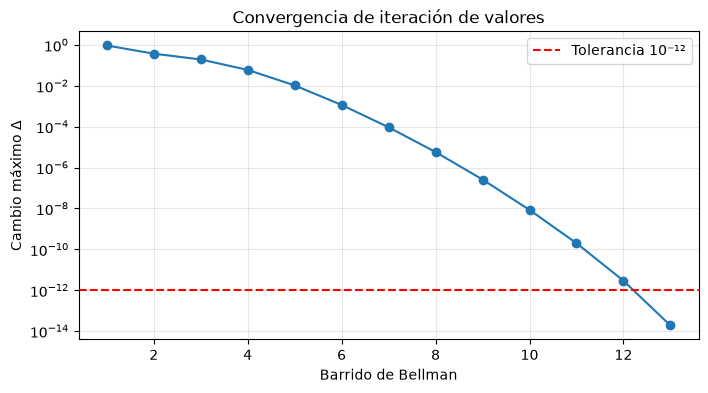

In [12]:
def value_iteration(gamma=1.0, tolerance=1e-12, max_sweeps=1000):
    V = {state: 0.0 for state in STATES}
    history = [V.copy()]
    deltas = []

    for sweep in range(1, max_sweeps + 1):
        new_V = bellman_sweep(V, gamma)
        delta = max(abs(new_V[s] - V[s]) for s in STATES)
        history.append(new_V.copy())
        deltas.append(delta)
        V = new_V

        if delta < tolerance:
            return V, history, deltas

    raise RuntimeError("Value iteration did not converge")


V_opt, history, deltas = value_iteration(gamma)
sweeps, final_delta = len(deltas), deltas[-1]
print(f"Convergió en {sweeps} barridos; delta final = {final_delta:.3e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, sweeps + 1), deltas, marker="o")
ax.axhline(1e-12, color="red", linestyle="--", label="Tolerancia 10⁻¹²")
ax.set_xlabel("Barrido de Bellman")
ax.set_ylabel("Cambio máximo Δ")
ax.set_title("Convergencia de iteración de valores")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 6. Ver la propagación de valor

Cada figura separa manos sin as utilizable y con as utilizable. Las filas son la suma del jugador y las columnas la carta visible del crupier (`A` representa el as). Mostramos las sumas 12 a 21, que son las más utilizadas para visualizar la estrategia de Blackjack.

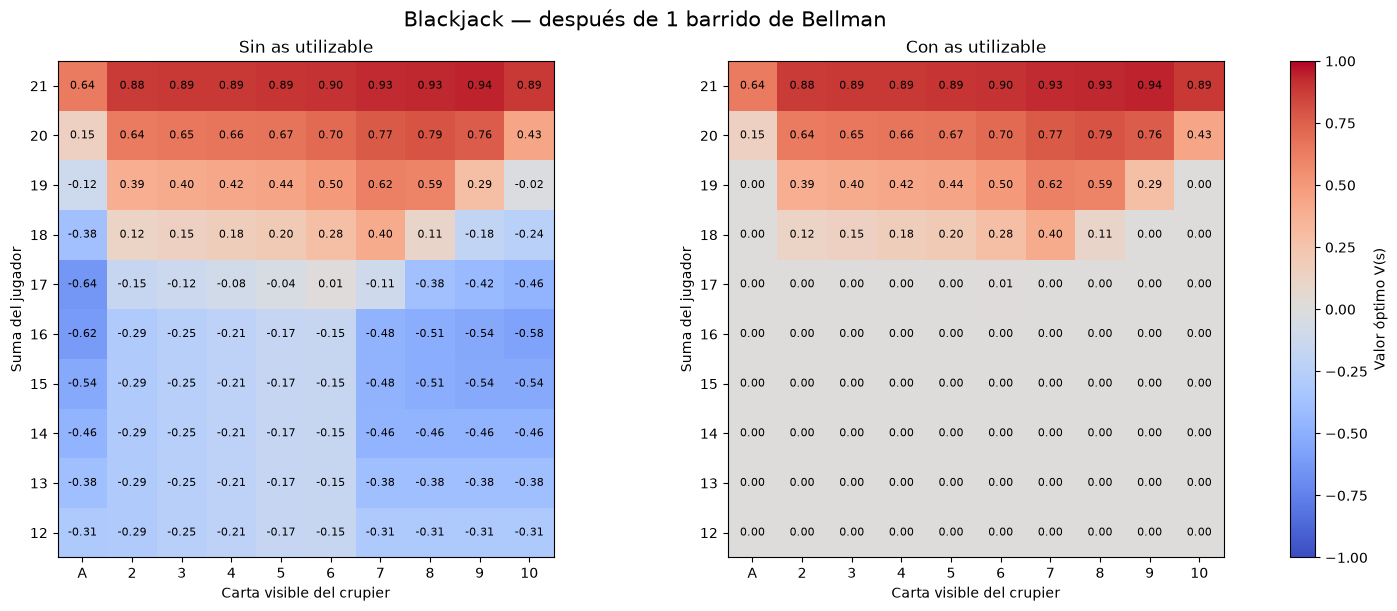

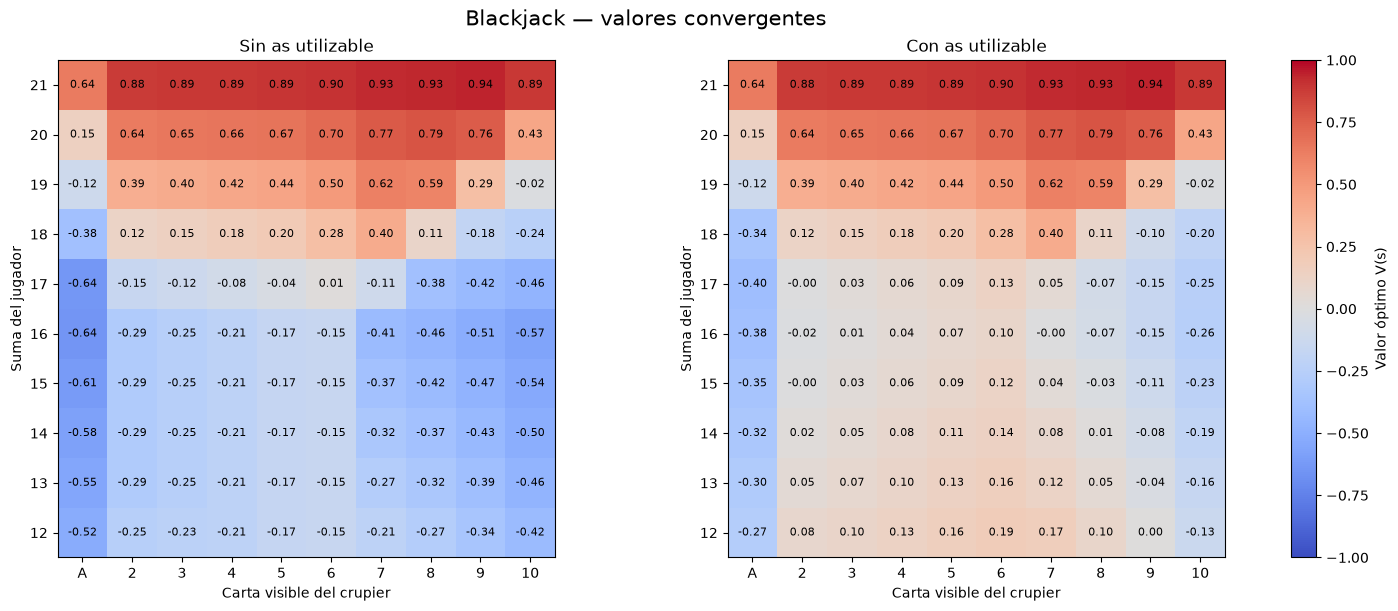

In [13]:
PLAYER_TOTALS = list(range(12, 22))
DEALER_LABELS = ["A"] + [str(card) for card in range(2, 11)]


def value_matrix(V, usable_ace):
    return np.array([
        [V[(player, dealer, usable_ace)] for dealer in range(1, 11)]
        for player in PLAYER_TOTALS
    ])


def show_values(V, title):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

    for ax, usable in zip(axes, (False, True)):
        matrix = value_matrix(V, usable)
        image = ax.imshow(matrix, origin="lower", cmap="coolwarm", vmin=-1, vmax=1)

        for row in range(matrix.shape[0]):
            for col in range(matrix.shape[1]):
                ax.text(col, row, f"{matrix[row, col]:.2f}",
                        ha="center", va="center", fontsize=8)

        ax.set_xticks(range(10), DEALER_LABELS)
        ax.set_yticks(range(10), PLAYER_TOTALS)
        ax.set_xlabel("Carta visible del crupier")
        ax.set_ylabel("Suma del jugador")
        ax.set_title("Con as utilizable" if usable else "Sin as utilizable")

    fig.colorbar(image, ax=axes, label="Valor óptimo V(s)")
    fig.suptitle(title, fontsize=15)
    plt.show()


show_values(history[1], "Blackjack — después de 1 barrido de Bellman")
show_values(V_opt, "Blackjack — valores convergentes")

## 7. Extraer la política greedy

Después de obtener `V*`, elegimos en cada estado la acción con mayor valor esperado. En las gráficas, `H` significa pedir (`HIT`) y `S` significa plantarse (`STICK`).

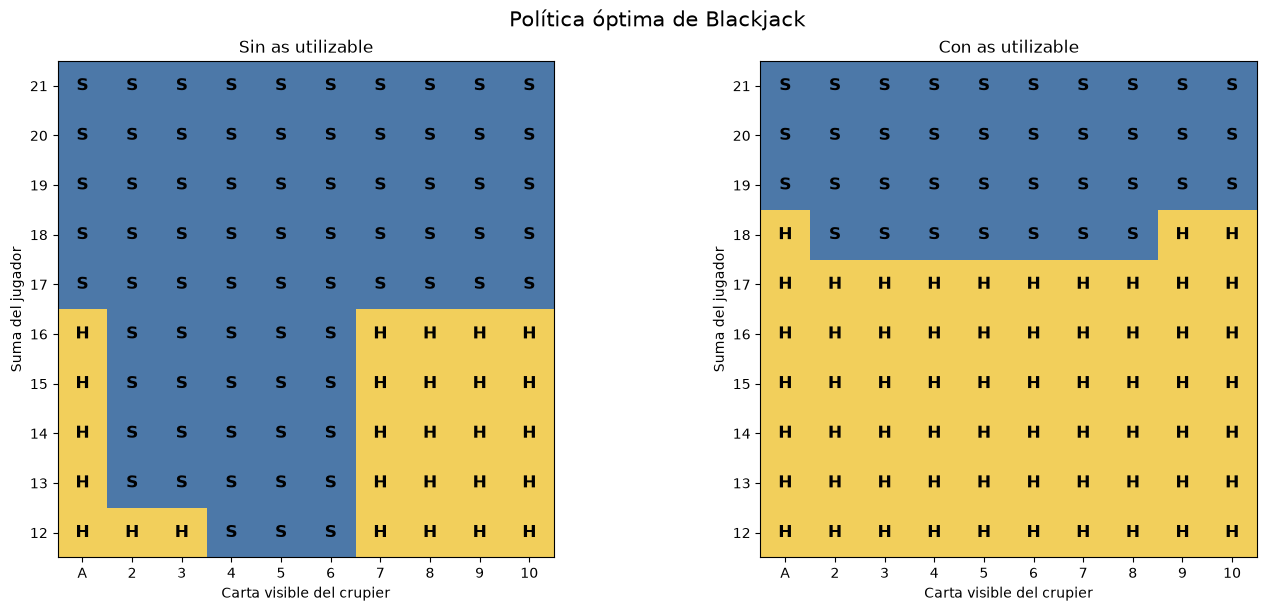

In [14]:
Q_opt = {state: action_values(state, V_opt, gamma) for state in STATES}
policy_opt = {state: int(np.argmax(Q_opt[state])) for state in STATES}


def policy_matrix(policy, usable_ace):
    return np.array([
        [policy[(player, dealer, usable_ace)] for dealer in range(1, 11)]
        for player in PLAYER_TOTALS
    ])


def show_policy(policy, title="Política óptima de Blackjack"):
    colors = ListedColormap(["#4C78A8", "#F2CF5B"])
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

    for ax, usable in zip(axes, (False, True)):
        matrix = policy_matrix(policy, usable)
        ax.imshow(matrix, origin="lower", cmap=colors, vmin=0, vmax=1)

        for row in range(matrix.shape[0]):
            for col in range(matrix.shape[1]):
                ax.text(col, row, "S" if matrix[row, col] == STICK else "H",
                        ha="center", va="center", fontsize=12, fontweight="bold")

        ax.set_xticks(range(10), DEALER_LABELS)
        ax.set_yticks(range(10), PLAYER_TOTALS)
        ax.set_xlabel("Carta visible del crupier")
        ax.set_ylabel("Suma del jugador")
        ax.set_title("Con as utilizable" if usable else "Sin as utilizable")

    fig.suptitle(title, fontsize=15)
    plt.show()


show_policy(policy_opt)

In [15]:
for state in example_states:
    q_stick, q_hit = Q_opt[state]
    action = "STICK" if policy_opt[state] == STICK else "HIT"
    print(f"{state}: Q(STICK)={q_stick:+.3f}, Q(HIT)={q_hit:+.3f} -> {action}")

(12, 2, False): Q(STICK)=-0.293, Q(HIT)=-0.253 -> HIT
(16, 10, False): Q(STICK)=-0.576, Q(HIT)=-0.569 -> HIT
(18, 9, True): Q(STICK)=-0.183, Q(HIT)=-0.101 -> HIT
(20, 10, False): Q(STICK)=+0.435, Q(HIT)=-0.855 -> STICK


## 8. Experimento solicitado: 100 partidas por política

El agente aleatorio elige `HIT` o `STICK` con probabilidad 1/2 en cada decisión. El agente de Bellman consulta `policy_opt`. Se usan las **mismas semillas por número de partida**, de modo que ambas políticas comienzan cada partida con la misma mano inicial y carta visible; las extracciones posteriores dependen de sus acciones.

Se reportan victorias, empates, derrotas, recompensa total y media. Cien partidas son una muestra pequeña: el resultado puntual puede variar con la semilla.

In [16]:
random_history = simulate_100_games(
    random_policy, "Aleatorio (sin conocimiento)", episodes=100, seed=2026
)
informed_history = simulate_100_games(
    optimal_policy, "Bellman (con conocimiento)", episodes=100, seed=2026
)

assert random_history["estado_inicial"].tolist() == informed_history["estado_inicial"].tolist()
experiment_history = pd.concat([random_history, informed_history], ignore_index=True)
experiment_history.head(10)

,agente,partida,estado_inicial,acciones,recompensa,resultado,recompensa_acumulada,recompensa_media_acumulada,tasa_victorias_acumulada
0,Aleatorio (sin conocimiento),1,"(20, 10, 1)",HIT -> STICK,-1,Derrota,-1,-1.000000,0.000000
1,Aleatorio (sin conocimiento),2,"(8, 9, 0)",STICK,-1,Derrota,-2,-1.000000,0.000000
2,Aleatorio (sin conocimiento),3,"(13, 8, 0)",HIT,-1,Derrota,-3,-1.000000,0.000000
3,Aleatorio (sin conocimiento),4,"(15, 4, 1)",STICK,-1,Derrota,-4,-1.000000,0.000000
4,Aleatorio (sin conocimiento),5,"(21, 1, 1)",STICK,1,Victoria,-3,-0.600000,0.200000
5,Aleatorio (sin conocimiento),6,"(12, 8, 0)",STICK,1,Victoria,-2,-0.333333,0.333333
6,Aleatorio (sin conocimiento),7,"(18, 5, 0)",STICK,0,Empate,-2,-0.285714,0.285714
7,Aleatorio (sin conocimiento),8,"(11, 10, 0)",HIT -> STICK,-1,Derrota,-3,-0.375000,0.250000
8,Aleatorio (sin conocimiento),9,"(15, 6, 0)",HIT,-1,Derrota,-4,-0.444444,0.222222
9,Aleatorio (sin conocimiento),10,"(15, 4, 0)",HIT,-1,Derrota,-5,-0.500000,0.200000


In [17]:
comparison_100 = pd.DataFrame({
    "Aleatorio (sin conocimiento)": experiment_summary(random_history),
    "Bellman (con conocimiento)": experiment_summary(informed_history),
}).T

comparison_100.round(2)

,partidas,victorias,empates,derrotas,recompensa total,recompensa media,porcentaje de victorias
Aleatorio (sin conocimiento),100.0,27.0,8.0,65.0,-38.0,-0.38,27.0
Bellman (con conocimiento),100.0,40.0,13.0,47.0,-7.0,-0.07,40.0


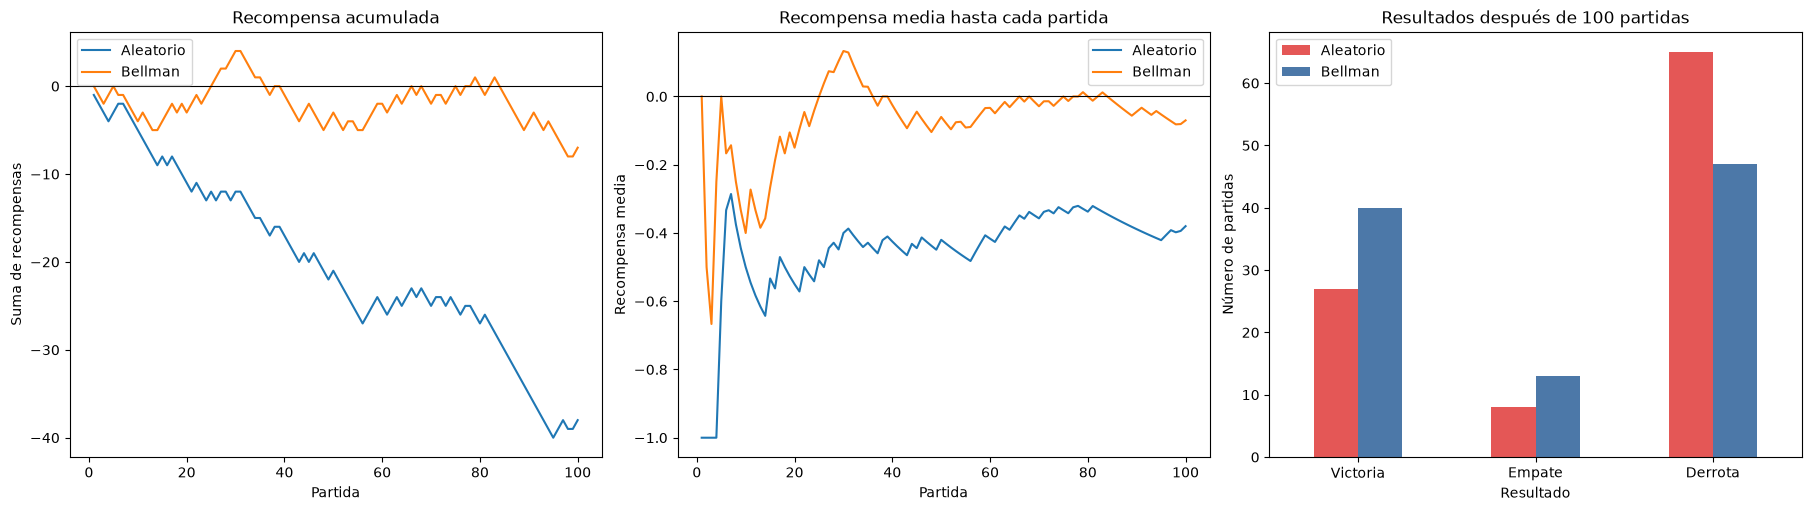

In [18]:
plot_100_games(random_history, informed_history)

### Cómo interpretar los resultados

La política de Bellman maximiza la **recompensa esperada**, no garantiza ganar todas las manos. La comparación de 100 partidas debe leerse con sus conteos concretos: si la ventaja observada es pequeña o se invierte, se debe a la variación de una muestra corta. La simulación amplia opcional permite ver la tendencia con más precisión.

# Conclusión

La distribución de cartas y la regla del crupier producen `P`. Bellman propaga el valor por `P` hasta que el cambio máximo es menor que la tolerancia; luego `argmax Q(s,a)` da `HIT` o `STICK` para cada estado. Las gráficas separan los estados con y sin as utilizable, y la evaluación final juega 100 partidas por política en `Blackjack-v1`.